# Medical Image Processing: Final Project
## Einar López Altamirano

# Task 3: 3D Image Segmentation

## Task 3B: General-Purpuse Segmentation Model

### Library Installation

In [ ]:
!pip install nninteractive

### Libraries

In [1]:
from google.colab import files
import os
from huggingface_hub import snapshot_download
import torch
from nnInteractive.inference.inference_session import nnInteractiveInferenceSession
import SimpleITK as sitk
%matplotlib inline
import matplotlib.pyplot as plt



nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
nnUNet_results is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.


### Registered MR File Import

In [2]:
files.upload()   # select data/processed/mr.nii.gz
print("File Uploaded")

Saving mr.nii.gz to mr.nii.gz
File Uploaded


### Pre-trained Model Download

In [3]:

REPO_ID, MODEL_NAME = "nnInteractive/nnInteractive", "nnInteractive_v1.0"
DOWNLOAD_DIR = "/content/nninteractive_model"
snapshot_download(repo_id=REPO_ID, allow_patterns=[f"{MODEL_NAME}/*"], local_dir=DOWNLOAD_DIR)
model_path = os.path.join(DOWNLOAD_DIR, MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

### Session Creation

In [4]:
session = nnInteractiveInferenceSession(
    device=torch.device("cuda:0"), use_torch_compile=False, verbose=False,
    torch_n_threads=os.cpu_count(), do_autozoom=True, use_pinned_memory=True,
)
session.initialize_from_trained_model_folder(model_path)

License reminder: The official nnInteractive checkpoint is licensed under Creative Commons Attribution Non Commercial Share Alike 4.0 (CC BY-NC-SA 4.0). See the license note in readme.md (# License).


### MR Setup In Session

In [5]:
input_image = sitk.ReadImage("mr.nii.gz")
img = sitk.GetArrayFromImage(input_image)[None]
print("image shape:", img.shape)

session.set_image(img)
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)
session.set_target_buffer(target_tensor)

image shape: (1, 156, 256, 256)


### Bounding Box Definition And Inference

In [6]:
z_slice = 66
BBOX = [[z_slice, z_slice + 1], [155, 201], [153, 189]]
# {'z_min': 43, 'z_max': 97, 'y_min': 155, 'y_max': 201, 'x_min': 153, 'x_max': 189}

session.add_bbox_interaction(BBOX, include_interaction=True)

Added new bbox interaction: center 1, scale [[66, 174, 171]]
Took 1.44 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 1.46s


### Tumor Mask Visualization

mask shape: (156, 256, 256) | total tumour voxels: 43267
voxels on slice 66 : 1485


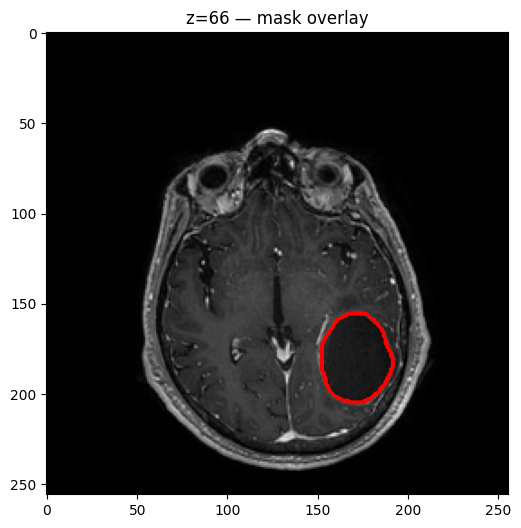

In [7]:
mask  = session.target_buffer.clone().cpu().numpy().astype("uint8")
mr_np = sitk.GetArrayFromImage(input_image)
print("mask shape:", mask.shape, "| total tumour voxels:", int(mask.sum()))
print("voxels on slice", z_slice, ":", int(mask[z_slice].sum()))

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mr_np[z_slice], cmap='gray')
if mask[z_slice].sum() > 0:
    ax.contour(mask[z_slice], colors='r')
ax.set_title(f'z={z_slice} — mask overlay')
plt.show()

### Tumor Mask Export

In [8]:
mask_img = sitk.GetImageFromArray(mask)
mask_img.CopyInformation(input_image)
sitk.WriteImage(mask_img, "tumor_mask.nii.gz")
files.download("tumor_mask.nii.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>